In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\Hp\\OneDrive\\Documents\\ola_cab_services.csv")
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for Cancelling by Customer,Cancelled Rides by Driver,Reason for Cancelling by Driver,Incomplete Rides,Incomplete Rides Reason,Booking Value,Payment Method,Ride Distance,Driver Ratings,Customer Rating
0,28-01-2024,06:00:00,CNR1721175,Success,329258,Auto,Area-3,Area-2,5.42,18.46,...,NaN,0,NaN,0,NaN,868.06,Wallet,28.50,4.4,4.4
1,26-01-2024,03:00:00,CNR2871422,Cancelled by Driver,201414,Mini,Area-7,Area-6,NaN,NaN,...,NaN,1,The customer was coughing/sick,0,NaN,NaN,NaN,NaN,NaN,NaN
2,15-01-2024,16:00:00,CNR6875935,Cancelled by Driver,301629,Bike,Area-40,Area-24,NaN,NaN,...,NaN,1,Personal & Car related issues,0,NaN,NaN,NaN,NaN,NaN,NaN
3,02-01-2024,22:00:00,CNR6798834,Cancelled by Driver,319684,Prime Sedan,Area-11,Area-24,NaN,NaN,...,NaN,1,The customer was coughing/sick,0,NaN,NaN,NaN,NaN,NaN,NaN
4,30-01-2024,22:00:00,CNR9661713,Incomplete,330283,Bike,Area-41,Area-45,NaN,NaN,...,NaN,0,NaN,1,Other Issue,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,02-01-2024,00:00:00,CNR7299340,Success,454202,eBike,Area-39,Area-34,11.53,2.42,...,NaN,0,NaN,0,NaN,1217.43,Card,10.52,4.1,3.2
49995,27-01-2024,02:00:00,CNR0378586,Success,349873,Auto,Area-17,Area-21,5.56,9.05,...,NaN,0,NaN,0,NaN,1369.51,UPI,11.04,5.0,4.3
49996,17-01-2024,23:00:00,CNR2461856,Cancelled by Driver,880053,Auto,Area-37,Area-43,NaN,NaN,...,NaN,1,More than permitted people in there,0,NaN,NaN,NaN,NaN,NaN,NaN
49997,18-01-2024,22:00:00,CNR9524579,Success,752806,eBike,Area-48,Area-29,5.15,13.72,...,NaN,0,NaN,0,NaN,1930.49,UPI,14.49,3.1,4.5


In [4]:
#U1] On which date were the minimum number of rides booked?
df["Date"].min()


'01-01-2024'

In [5]:
#U2] On which date were the maximum number of rides booked?
df["Date"].max()

'31-01-2024'

In [163]:
#U3] On which date were the most rides booked?
df["Date"].value_counts().idxmax()

'12-01-2024'

In [133]:
#U4] How many unique dates are in the dataset?
df['Date'].nunique()


31

In [135]:
#U5]How many rides were booked on 01-01-2024?
df[df['Date'] == '01-01-2024'].shape[0]



1639

In [46]:
#U6]How many rides were booked on 31-01-2024?
df[df['Date'] == '24-01-2024'].shape[0]


1635

In [136]:
#U7Which date had exactly 1635 rides?
df['Date'].value_counts()[df['Date'].value_counts()==1635]


Date
2024-01-16    1635
2024-01-24    1635
Name: count, dtype: int64

In [54]:
#U8]How many rides were booked on weekends?
df[df['Date'].dt.dayofweek >= 5].shape[0]


13201

In [55]:
#U9]How many rides were booked on weekdays?
df[df['Date'].dt.dayofweek < 5].shape[0]


36798

In [137]:
#U10]Which day of the week had the most bookings?
df['Date'].dt.day_name().value_counts().idxmax()


'Monday'

In [57]:
#U11] Which day of the week had the least bookings?
df['Date'].dt.day_name().value_counts().idxmin()


'Saturday'

In [50]:
#U12] How many unique bookings are present in the Booking ID column?
df['Booking ID'].nunique()
                                

49866

In [28]:
#U13]  Which Booking ID is the most common?
df["Booking ID"].value_counts().idxmax()


'CNR3698787'

In [6]:
#U14] What is the total number of Booking IDs in the dataset?
df["Booking ID"].count()


np.int64(49999)

In [138]:
#U15 Are there any duplicate booking IDs?
df['Booking ID'].duplicated().sum()


np.int64(133)

In [7]:
#U16 What is the data type of Booking ID?
df['Booking ID'].dtype


dtype('O')

In [8]:
#U17 What is the minimum Booking ID?
df['Booking ID'].min()


'CNR0000000'

In [150]:
#U18]What is the maximum Booking ID?
df['Booking ID'].max()



'CNR9999522'

In [76]:
#U19]Do booking IDs follow a continuous sequence?
df['Booking ID'].nunique() == len(df)


False

In [77]:
#U20]How many booking IDs contain only numbers?
df['Booking ID'].str.isnumeric().sum()


np.int64(0)

In [78]:
#U21] Find the first 5 booking IDs.
df['Booking ID'].head()


0    CNR1721175
1    CNR2871422
2    CNR6875935
3    CNR6798834
4    CNR9661713
Name: Booking ID, dtype: object

In [79]:
#U22] Find the last 5 booking IDs.
df['Booking ID'].tail()


49994    CNR7299340
49995    CNR0378586
49996    CNR2461856
49997    CNR9524579
49998    CNR3698787
Name: Booking ID, dtype: object

In [151]:
#U23] How many unique booking status are there?
df['Booking Status'].nunique()


4

In [81]:
#U24] What are the counts of each booking status?
df['Booking Status'].value_counts()


Booking Status
Success                  33484
Cancelled by Driver       9610
Cancelled by Customer     3799
Incomplete                3106
Name: count, dtype: int64

In [152]:
#U25] What percentage of rides were completed?
(df['Booking Status'].value_counts(normalize=True)* 100)


Booking Status
Success                  66.969339
Cancelled by Driver      19.220384
Cancelled by Customer     7.598152
Incomplete                6.212124
Name: proportion, dtype: float64

In [153]:
#U26] Which status is most frequent?
df['Booking Status'].mode()[0]


'Success'

In [159]:
#U27] Which status is least frequent?
df['Booking Status'].value_counts().idxmin()


'Incomplete'

In [86]:
#U28]How many pending rides are there?
(df['Booking Status'] == 'Pending').sum()


np.int64(0)

In [160]:
#U29] What is the ratio of success to incomplete rides?
(df['Booking Status'].value_counts()['Success'] / 
 df['Booking Status'].value_counts()['Incomplete'])


np.float64(10.780424983902124)

In [58]:
#U30] What is the distribution of Booking Status in the dataset?
df['Booking Status'].value_counts()


Booking Status
Success                  33403
Cancelled by Driver       9582
Cancelled by Customer     3782
Incomplete                3099
Name: count, dtype: int64

In [61]:
#U31] How many unique Customer IDs are present in the dataset?
df["Customer ID"].nunique()


48542

In [67]:
#U32]Which are the top 10 most frequently used Customer IDs in the dataset?
df['Customer ID'].head(10) 

0    329258
1    201414
2    301629
3    319684
4    330283
5    787277
6    329974
7    663054
8    656116
9    676510
Name: Customer ID, dtype: int64

In [10]:
#U33] How many rides were booked by the most frequent customer?
df['Customer ID'].value_counts().idxmax()


np.int64(844154)

In [12]:
#U34] Which customer booked the minimum rides
df['Customer ID'].value_counts().idxmin()


np.int64(698087)

In [169]:
#U35] How many customers booked only 1 ride?
(df['Customer ID'].value_counts() == 1).sum()


np.int64(47359)

In [98]:
#U36] How many customers booked more than 10 rides?
(df['Customer ID'].value_counts() > 10).sum()


np.int64(0)

In [170]:
#U37] What is the average number of rides per customer?
df['Customer ID'].value_counts().mean()


np.float64(1.0273274569027513)

In [171]:
#U38] How many customers booked exactly 2 rides?
(df['Customer ID'].value_counts() == 2).sum()


np.int64(1290)

In [102]:
#U39] What is the median number of rides per customer?
df['Customer ID'].value_counts().median()


1.0

In [104]:
#U40] Which vehicle type is the most commonly booked in the dataset?
df["Vehicle Type"].mode()


0    Prime Plus
Name: Vehicle Type, dtype: object

In [13]:
#U41] Most frequently used vehicle?
df['Vehicle Type'].head(1)


0    Auto
Name: Vehicle Type, dtype: object

In [164]:
#U42] Least frequently used vehicle? 
df['Vehicle Type'].tail()

49994    eBike
49995     Auto
49996     Auto
49997    eBike
49998     Bike
Name: Vehicle Type, dtype: object

In [174]:
#U43] How many unique vehicle types are there?
df['Vehicle Type'].nunique()


7

In [106]:
#U44] What are the counts of each vehicle type?
df['Vehicle Type'].value_counts()


Vehicle Type
Prime Plus     7252
Bike           7223
Prime Sedan    7179
Prime SUV      7140
Auto           7098
eBike          7097
Mini           7010
Name: count, dtype: int64

In [186]:
#U45] Which vehicle type is used most frequently?
df['Vehicle Type'].value_counts().idxmax()


'Prime Plus'

In [189]:
#U46] Which vehicle type is least used?
df['Vehicle Type'].value_counts().idxmin()


'Mini'

In [191]:
#U47] What percentage of rides are Auto bookings?
(df['Vehicle Type'].value_counts(normalize=True) * 100).loc['Auto']


np.float64(14.196283925678513)

<Axes: xlabel='Vehicle Type'>

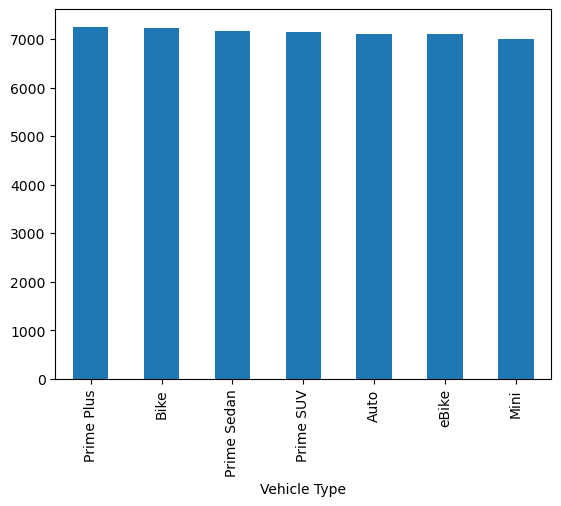

In [111]:
#U48] Plot vehicle type distribution as a bar chart.
df['Vehicle Type'].value_counts().plot(kind='bar')


In [81]:
#U49] How many unique pickup locations are there in the dataset?
df['Pickup Location'].nunique()

50

In [97]:
#U50] Which pickup location is used the most in the dataset?
df['Pickup Location'].value_counts().idxmax()

'Area-39'

In [98]:
#u51] Which pickup location is the least used in the dataset?
df['Pickup Location'].value_counts().idxmin()

'Area-37'

In [112]:
#U52] What are the top 10 most common pickup locations?
df['Pickup Location'].value_counts().head(10)


Pickup Location
Area-39    1100
Area-4     1057
Area-8     1049
Area-29    1045
Area-9     1040
Area-44    1039
Area-11    1038
Area-48    1035
Area-22    1034
Area-1     1027
Name: count, dtype: int64

In [195]:
#U53] What are the bottom 10 least common pickup locations?
df['Pickup Location'].value_counts().tail(10)


Pickup Location
Area-36    969
Area-31    969
Area-32    965
Area-21    964
Area-2     963
Area-35    962
Area-27    956
Area-7     955
Area-14    954
Area-37    945
Name: count, dtype: int64

<Axes: xlabel='Pickup Location'>

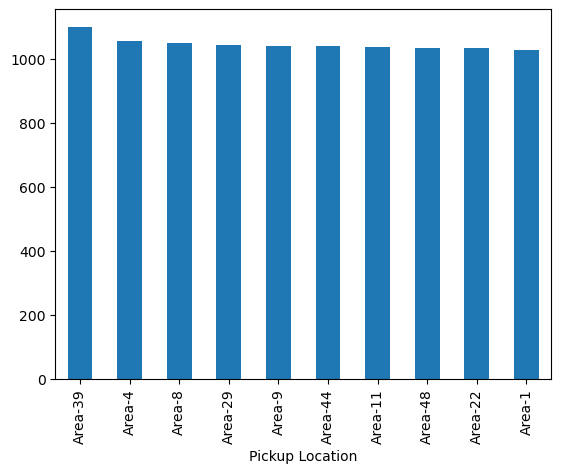

In [119]:
#U54] Plot top 10 pickup locations as a bar chart.
df['Pickup Location'].value_counts().head(10).plot(kind='bar')


In [101]:
#U55] How many unique drop locations are present in the dataset?
df['Drop Location'].nunique()


50

In [120]:
#U56] Which drop location has the highest number of rides?
df['Drop Location'].value_counts().idxmax()


'Area-39'

In [198]:
#U57] Which drop location has the least number of rides?
df['Drop Location'].value_counts().idxmin()


'Area-16'

In [201]:
#58] Show the top 5 drop locations by ride count.
df['Drop Location'].value_counts().head(5)


Drop Location
Area-39    1058
Area-8     1052
Area-21    1049
Area-34    1042
Area-27    1041
Name: count, dtype: int64

In [105]:
#U59] How many null values are present in the Avg VTAT column?
df['Avg VTAT'].isnull().sum()

np.int64(16515)

In [106]:

#U60] What is the total data present in Avg VTAT?
df['Avg VTAT'].notnull().sum()

np.int64(33484)

In [108]:
#U61] What is the total data present in Avg CTAT?
df["Avg CTAT"].notnull().sum()

np.int64(33484)

In [14]:
#U62]What is the most common reason for cancellation by driver?
df['Reason for Cancelling by Driver'].value_counts().head(1)

Reason for Cancelling by Driver
More than permitted people in there    2512
Name: count, dtype: int64

In [113]:
#U63] How many null values are there in Booking Value?
df['Booking Value'].isnull().sum()

np.int64(16515)

In [124]:
#U64] What is the maximum booking value recorded in the dataset?
df['Booking Value'].max()

2000.0

In [132]:
#U65] What are Q1, Q2, and Q3 of Booking Value?
df['Booking Value'].quantile([0.25, 0.5, 0.75])

0.25     532.9425
0.50    1023.3500
0.75    1514.6775
Name: Booking Value, dtype: float64

<Axes: xlabel='Booking Value'>

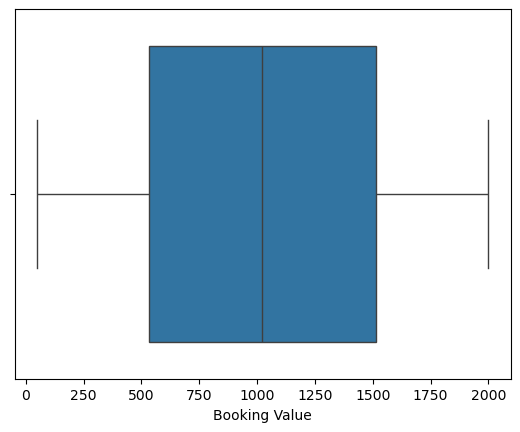

In [8]:
#U66] show the box plot of booking value in my dataset?
sns.boxplot(x=df['Booking Value'])


In [136]:
#U67] How many payment options are there in the dataset?
df['Payment Method'].unique()

array(['Wallet', nan, 'Card', 'UPI', 'Cash'], dtype=object)

In [140]:
#U68] What is the most used payment option in the dataset?
df['Payment Method'].value_counts().head(1)

Payment Method
Cash    8552
Name: count, dtype: int64

In [213]:
#69] Which payment method is used least frequently?
df['Payment Method'].value_counts().idxmin()


'Wallet'

In [148]:
#U70] What is the average ride distance in the dataset?
df["Ride Distance"].mean()

np.float64(25.447143113128657)

In [123]:
#U71] What is the median ride distance?
df['Ride Distance'].median()


25.46

In [124]:
#U72] What is the maximum ride distance recorded?
df['Ride Distance'].max()


50.0

In [125]:
#U73] What is the minimum ride distance recorded?
df['Ride Distance'].min()


1.0

In [224]:
#U74] How many rides are shorter than 5 km?
(df['Ride Distance'] < 5).sum()


np.int64(2767)

In [225]:
#U75] How many rides are between 5 and 15 km?
df[(df['Ride Distance'] >= 5) & (df['Ride Distance'] <= 15)].shape[0]


6912

In [128]:
#U76] How many rides are above 30 km?
(df['Ride Distance'] > 30).sum()


np.int64(13602)

In [129]:
#U77] What is the standard deviation of ride distances?
df['Ride Distance'].std()


14.175952875908354

In [149]:
#U78] What is the average rating given by the driver?
df['Driver Ratings'].mean()

np.float64(4.003040258033687)

In [156]:
#U79] How many customers gave a 5* rating?
(df['Customer Rating'] == 5).sum()

np.int64(793)

In [226]:
#U80] How many customers did not give any rating?
df['Customer Rating'].isna().sum()

np.int64(16515)